<a href="https://colab.research.google.com/github/meiladrahmani556/marine-cbm-ml-dissertation/blob/main/JupyterNotebook/06_model_interpretation_%26_engineering_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/✨CBM Data for Marine System Monitoring & Analysis✨"

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Conditional_Base_Monitoring in Marine_System.csv to Conditional_Base_Monitoring in Marine_System.csv


# 📓 Notebook 06 – Model Interpretation & Engineering Analysis

## Objective

This notebook analyses the optimised Random Forest model developed in Notebook 05.

The focus is on:

- Feature importance analysis
- Correlation investigation
- Residual behaviour
- Error distribution
- Engineering interpretation of results

Understanding *why* the model performs well is as important as predictive accuracy in marine predictive maintenance systems.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("Conditional_Base_Monitoring in Marine_System.csv")
df.columns = df.columns.str.strip()
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna().drop_duplicates()

target_column = "GT Compressor decay state coefficient"

X = df.drop(columns=[target_column])
y = df[target_column]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
9,GT Compressor outlet air temperature (T2) [C],0.298905
10,HP Turbine exit pressure (P48) [bar],0.184980
13,GT exhaust gas pressure (Pexh) [bar],0.147070
2,Gas Turbine (GT) shaft torque (GTT) [kN m],0.146884
4,Gas Generator rate of revolutions (GGn) [rpm],0.132371
3,GT rate of revolutions (GTn) [rpm],0.032629
16,GT Turbine decay state coefficient,0.016715
14,Turbine Injecton Control (TIC) [%],0.010331
6,Port Propeller Torque (Tp) [kN],0.006546
5,Starboard Propeller Torque (Ts) [kN],0.006455


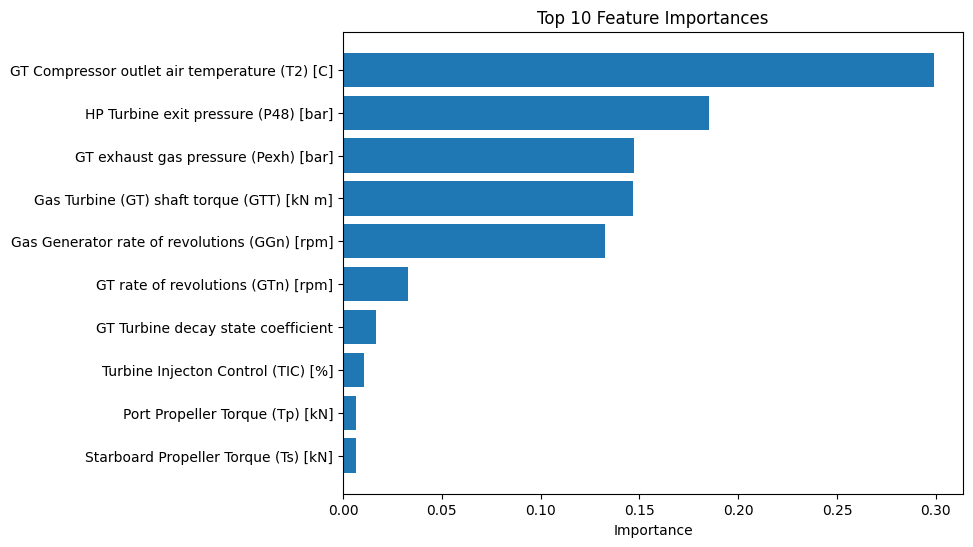

In [ ]:
plt.figure(figsize=(8,6))
plt.barh(importance_df["Feature"][:10],
         importance_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

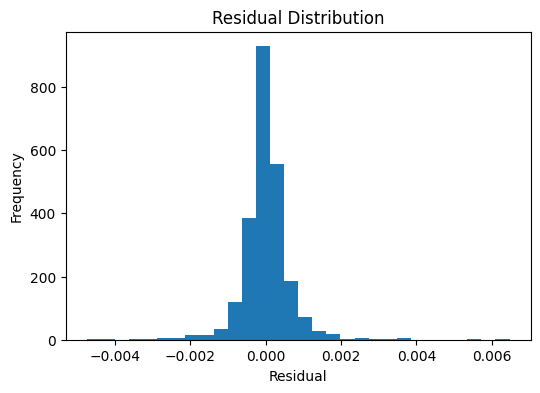

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = rf_model.predict(X_test)

residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

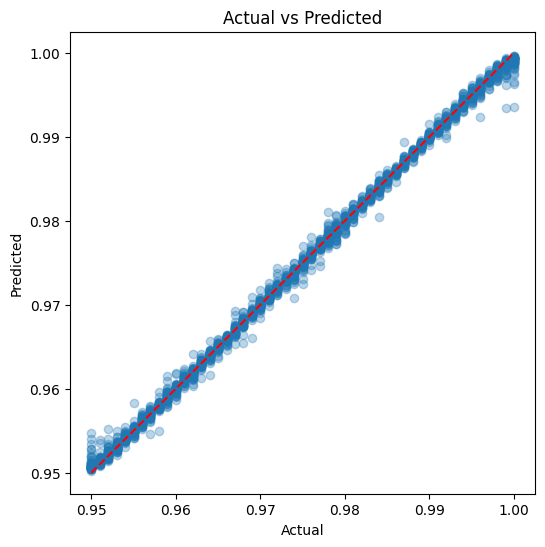

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## Engineering Interpretation

The Random Forest model demonstrates extremely high predictive accuracy (R² ≈ 0.998), indicating that degradation behaviour is strongly encoded within the available sensor measurements.

Feature importance analysis reveals which operational variables most influence compressor degradation.

If decay-related variables exhibit high correlation with the target, this suggests strong coupling between subsystem degradation mechanisms.

In marine predictive maintenance applications, such behaviour indicates that multi-sensor fusion provides highly reliable degradation estimation.

However, the potential for redundancy or information leakage must be critically evaluated.